# Predictive Analysis- Data Preprocessing (REGRESSION)

This notebook preprocesses our dataset and merges the 5 individual datasets into a master dataset, with target variables for Remaining Useful Life (RUL) prediction (regression).


In [ ]:
%pip install pandas numpy matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Loading all datasets


In [ ]:
DATA_PATH = '/content/drive/MyDrive/predictive-analysis-data/raw/'

telemetry_df = pd.read_csv(f'{DATA_PATH}PdM_telemetry.csv', parse_dates=['datetime'])
errors_df = pd.read_csv(f'{DATA_PATH}PdM_errors.csv', parse_dates=['datetime'])
maintenance_df = pd.read_csv(f'{DATA_PATH}PdM_maint.csv', parse_dates=['datetime'])
failures_df = pd.read_csv(f'{DATA_PATH}PdM_failures.csv', parse_dates=['datetime'])
machines_df = pd.read_csv(f'{DATA_PATH}PdM_machines.csv')

print(f"Telemetry: {len(telemetry_df):,} rows")
print(f"Errors: {len(errors_df):,} rows")
print(f"Maintenance: {len(maintenance_df):,} rows")
print(f"Failures: {len(failures_df):,} rows")
print(f"Machines: {len(machines_df):,} rows")


Telemetry: 876,100 rows
Errors: 3,919 rows
Maintenance: 3,286 rows
Failures: 761 rows
Machines: 100 rows


### Data filtering
Our dataset has maintainance data from 2014 but other data (like failure, telementry) starts from 2015. So, we need to filter our maintainace data to match other dataset and start from 2015.


In [ ]:
print(f"Before: {len(maintenance_df):,} rows")
print(f"Date range: {maintenance_df['datetime'].min()} to {maintenance_df['datetime'].max()}")

maintenance_df = maintenance_df[maintenance_df['datetime'] >= '2015-01-01']

print(f"After: {len(maintenance_df):,} rows")
print(f"Date range: {maintenance_df['datetime'].min()} to {maintenance_df['datetime'].max()}")


Before: 3,286 rows
Date range: 2014-06-01 06:00:00 to 2016-01-01 06:00:00
After: 2,886 rows
Date range: 2015-01-01 06:00:00 to 2016-01-01 06:00:00


### Preparing events data

In this part, we are processing events data (errors, maintenance, failures) for each machine at every hour, and creating 3 pivot tables where each row represents the event status of a specific machine at a specific time. These tables include binary flags for each event type showing whether any event occurred during that time.
<br>This structure makes it easier to analyze a machine's condition over time: "when & what event happened to this machine?" and will be merged into master dataset later.


In [ ]:
# Processing ERROR events
errors_pivot = errors_df.pivot_table(
    index=['machineID', 'datetime'],
    columns='errorID',
    aggfunc='size',
    fill_value=0
).reset_index()

errors_pivot.columns = ['machineID', 'datetime'] + [f'{col}' for col in errors_pivot.columns[2:]]
errors_pivot['has_error'] = (errors_pivot.iloc[:, 2:].sum(axis=1) > 0).astype(int)

print(f"Error pivot columns: {list(errors_pivot.columns)}")


Error pivot columns: ['machineID', 'datetime', 'error1', 'error2', 'error3', 'error4', 'error5', 'has_error']


In [ ]:
# Processing MAINTENANCE events
maintenance_pivot = maintenance_df.pivot_table(
    index=['machineID', 'datetime'],
    columns='comp',
    aggfunc='size',
    fill_value=0
).reset_index()

maintenance_pivot.columns = ['machineID', 'datetime'] + [f'maint_{col}' for col in maintenance_pivot.columns[2:]]
maintenance_pivot['has_maintenance'] = (maintenance_pivot.iloc[:, 2:].sum(axis=1) > 0).astype(int)

print(f"Maintenance columns: {list(maintenance_pivot.columns)}")


Maintenance columns: ['machineID', 'datetime', 'maint_comp1', 'maint_comp2', 'maint_comp3', 'maint_comp4', 'has_maintenance']


In [ ]:
# Processing FAILURE events
failures_pivot = failures_df.pivot_table(
    index=['machineID', 'datetime'],
    columns='failure',
    aggfunc='size',
    fill_value=0
).reset_index()

failures_pivot.columns = ['machineID', 'datetime'] + [f'failure_{col}' for col in failures_pivot.columns[2:]]
failures_pivot['has_failure'] = (failures_pivot.iloc[:, 2:].sum(axis=1) > 0).astype(int)

print(f"Failure columns: {list(failures_pivot.columns)}")


Failure columns: ['machineID', 'datetime', 'failure_comp1', 'failure_comp2', 'failure_comp3', 'failure_comp4', 'has_failure']


### Merging dataset

Here, we are merging all our datasets into one master dataset. <br>
We take the telementry dataset as the base table by making a copy of it first, then do a left join on each of our pivoted events table one by one on the columns of machineID and datetime. Any row with a missing event data will be assinged a 'NaN' value on merge so we replace the NaN values with 0, representing the event as false for that entry.


In [ ]:
# making a copy of telemetry data as the base
master_df = telemetry_df.copy()

# merging with machines dataset (no datetime on this)
master_df = master_df.merge(machines_df, on='machineID', how='left')

# merging with errors pivot dataset, replacing all NaN values with 0
master_df = master_df.merge(errors_pivot, on=['machineID', 'datetime'], how='left')
error_cols = [col for col in master_df.columns if col.startswith('error') or col == 'has_error']
master_df[error_cols] = master_df[error_cols].fillna(0).astype(int)

# merging with maintenance pivot dataset, replacing all NaN values with 0
master_df = master_df.merge(maintenance_pivot, on=['machineID', 'datetime'], how='left')
maint_cols = [col for col in master_df.columns if col.startswith('maint_') or col == 'has_maintenance']
master_df[maint_cols] = master_df[maint_cols].fillna(0).astype(int)

# mergeing with failures pivot dataset, replacing all NaN values with 0
master_df = master_df.merge(failures_pivot, on=['machineID', 'datetime'], how='left')
failure_cols = [col for col in master_df.columns if col.startswith('failure_') or col == 'has_failure']
master_df[failure_cols] = master_df[failure_cols].fillna(0).astype(int)

master_df = master_df.sort_values(['machineID', 'datetime']).reset_index(drop=True)

print(f"Merged dataset: {len(master_df):,} rows, {master_df.shape[1]} columns")


Merged dataset: 876,100 rows, 24 columns


In [ ]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   datetime         876100 non-null  datetime64[ns]
 1   machineID        876100 non-null  int64         
 2   volt             876100 non-null  float64       
 3   rotate           876100 non-null  float64       
 4   pressure         876100 non-null  float64       
 5   vibration        876100 non-null  float64       
 6   model            876100 non-null  object        
 7   age              876100 non-null  int64         
 8   error1           876100 non-null  int64         
 9   error2           876100 non-null  int64         
 10  error3           876100 non-null  int64         
 11  error4           876100 non-null  int64         
 12  error5           876100 non-null  int64         
 13  has_error        876100 non-null  int64         
 14  maint_comp1      876

### Creating RUL (Remaining Useful Life) Target Variable

For regression analysis, we calculate the Remaining Useful Life (RUL) - the time in hours until the next failure for each machine and component. If no failure occurs, we set RUL to a maximum value of 24 hours as we are only looking into RUL of the machines components after we know that the machine is going to fail.


In [ ]:
def create_rul_target(master_df, window_hours=24):
    """
    Create RUL targets (24 hours default) for the master dataset.
    """
    df = master_df.copy()
    df = df.sort_values(["machineID", "datetime"])
    df["RUL_hours"] = np.nan

    window = pd.Timedelta(hours=window_hours)

    # loop machine by machine
    for m_id, machine_df in df.groupby("machineID"):

        failure_times = machine_df.loc[machine_df["has_failure"] == 1, "datetime"]
        if failure_times.empty:
            continue

        # work with only this machine's rows
        machine_slice_idx = machine_df.index

        for t_fail in failure_times:

            # compute start of RUL window
            window_start = t_fail - window

            # extract only rows for this machine inside the 24h window
            window_slice = machine_df[
                (machine_df["datetime"] >= window_start) &
                (machine_df["datetime"] <= t_fail)
            ]

            # compute RUL = time difference in hours
            rul_values = (t_fail - window_slice["datetime"]).dt.total_seconds() / 3600.0

            # assign back to the main dataframe using original indexes
            df.loc[window_slice.index, "RUL_hours"] = rul_values

    return df

In [ ]:
master_df = create_rul_target(master_df, 24)
print("\nMaster dataframe updated with RUL (Remaining Useful Life) target variables.")



Master dataframe updated with RUL (Remaining Useful Life) target variables.


In [ ]:
# Display RUL statistics
print("\nRUL Statistics:")
print(master_df[['RUL_hours']].describe())



RUL Statistics:
          RUL_hours
count  17902.000000
mean      11.970506
std        7.198280
min        0.000000
25%        6.000000
50%       12.000000
75%       18.000000
max       24.000000


### Visualizing RUL Distribution


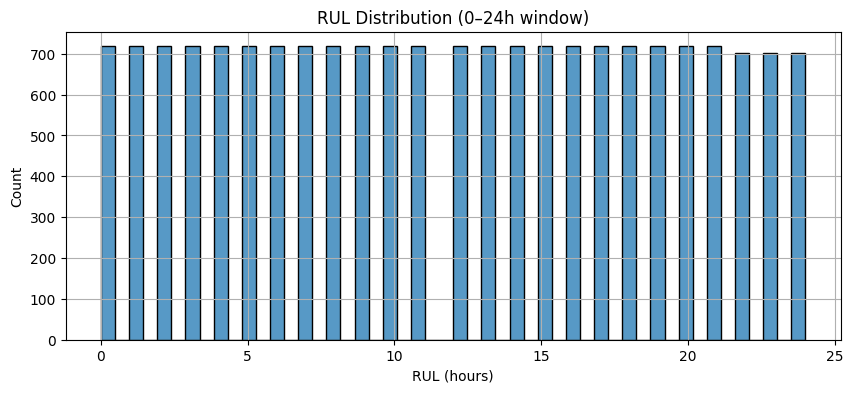

In [ ]:
# Plot RUL distribution

rul_vals = master_df["RUL_hours"].dropna()

plt.figure(figsize=(10,4))
sns.histplot(rul_vals, bins=50)
plt.title("RUL Distribution (0–24h window)")
plt.xlabel("RUL (hours)")
plt.ylabel("Count")
plt.grid(True)
plt.show()


### Storing the master regression dataset with metadata

Here, we save our master dataset as csv to be used for regression modeling and we also save its column metadata for easier context & schema access


In [ ]:

import os

OUTPUT_PATH = "drive/MyDrive/predictive-analysis-data/regression/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

# export as csv
master_df.to_csv(f"{OUTPUT_PATH}master_rul_24h.csv", index=False)



In [ ]:
# save column metadata
import json

column_info = {
    'total_columns': master_df.shape[1],
    'identifier_columns': ['machineID', 'datetime'],
    'sensor_columns': ['volt', 'rotate', 'pressure', 'vibration'],
    'machine_columns': ['model', 'age'],
    'error_columns': [col for col in master_df.columns if col.startswith('error')],
    'maintenance_columns': [col for col in master_df.columns if col.startswith('maint_')],
    'failure_columns': [col for col in master_df.columns if col.startswith('failure_')],
    'target_columns': [col for col in master_df.columns if col.startswith('RUL')],
    'target_type': 'regression',
    'max_rul_hours': 24
}

metadata_file = f'{OUTPUT_PATH}regression_preprocessing_metadata.json'
with open(metadata_file, 'w') as f:
    json.dump(column_info, f, indent=2)

print(f"Saved metadata to: {metadata_file}")


Saved metadata to: drive/MyDrive/predictive-analysis-data/regression/regression_preprocessing_metadata.json


### Summary of the regression dataset


In [ ]:
# Calculate summary statistics
rul_stats = master_df['RUL_hours'].describe()

summary_stats = {
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Date Range',
        'Number of Machines',
        'Target Type',
        'Mean RUL (hours)',
        'Median RUL (hours)',
        'Min RUL (hours)',
        'Max RUL (hours)',
        'Machines with Failures',
        'Total Error Events',
        'Total Maintenance Events',
        'Total Failure Events'
    ],
    'Value': [
        f"{len(master_df):,}",
        master_df.shape[1],
        f"{master_df['datetime'].min().date()} to {master_df['datetime'].max().date()}",
        master_df['machineID'].nunique(),
        "RUL (Remaining Useful Life)",
        f"{rul_stats['mean']:.2f}",
        f"{rul_stats['50%']:.2f}",
        f"{rul_stats['min']:.2f}",
        f"{rul_stats['max']:.2f}",
        f"{master_df[master_df['has_failure'] == 1]['machineID'].nunique()}/{master_df['machineID'].nunique()}",
        f"{master_df['has_error'].sum():,}",
        f"{master_df['has_maintenance'].sum():,}",
        f"{master_df['has_failure'].sum():,}"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print("\n")
print(summary_df.to_string(index=False))




                  Metric                       Value
              Total Rows                     876,100
           Total Columns                          25
              Date Range    2015-01-01 to 2016-01-01
      Number of Machines                         100
             Target Type RUL (Remaining Useful Life)
        Mean RUL (hours)                       11.97
      Median RUL (hours)                       12.00
         Min RUL (hours)                        0.00
         Max RUL (hours)                       24.00
  Machines with Failures                      98/100
      Total Error Events                       3,616
Total Maintenance Events                       2,163
    Total Failure Events                         719
